In [17]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
import os
import numpy as np

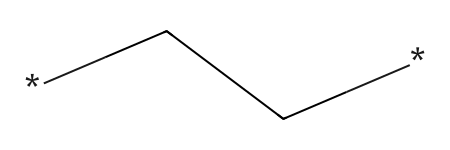

In [3]:
p1 = Chem.MolFromSmiles("*CC*")
p1

Download PI1M from https://github.com/RUIMINMA1996/PI1M

Then convert the .csv of smiles to .sdf and filter out the polymers containing Si and P

In [20]:
with Chem.SDWriter('../data/PI1M/PI1M.sdf') as w:
    with open("../data/PI1M/PI1M.csv",'r') as file:
        text = [i for i in file]
        for smile in text[1:]:
            if "Si" in smile or "P" in smile:
                continue
            w.write(Chem.MolFromSmiles(smile))

In [ ]:
suppl = Chem.SDMolSupplier('../data/PI1M/PI1M.sdf')


24


In [11]:
pols = []
for i in range(100):
    pols.append(suppl[i])

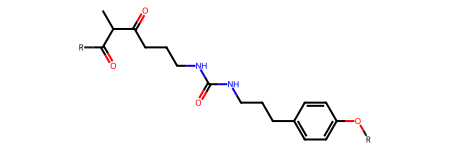

In [13]:
pols[5]

In [23]:
fpgen = AllChem.GetMorganGenerator(radius = 2)
fingerprints = [fpgen.GetSparseCountFingerprint(pol) for pol in pols]

similarity_matrix = np.zeros((len(fingerprints),len(fingerprints)))
for x in range(len(fingerprints)):
    for y in range(x+1,len(fingerprints)):
        similarity_matrix[x,y] = DataStructs.DiceSimilarity(fingerprints[x],fingerprints[y])


In [26]:
np.where(similarity_matrix == similarity_matrix.max())

(array([27]), array([65]))

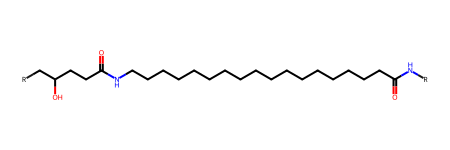

In [31]:
pols[27]

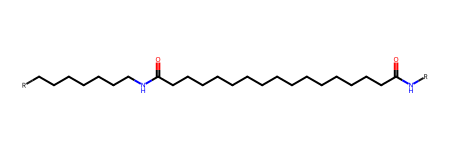

In [32]:
pols[65]